# Discrete-time Projection Reduction: k-bit Flip-Flop (2D/3D latent)

This notebook plots the results produced by:

- `experiments/run_discrete_reduction_flipflop_kbit.py`

It is designed to be run *after* the experiment completes (fast), but it also supports an optional “run first” mode.


## What to run

1. Run the experiment script (if you haven't yet), then this notebook will load the saved images.

2. If you set `RUN_EXPERIMENT = True`, this notebook will launch the script for you.


In [19]:
from pathlib import Path
import glob

# ===== User settings =====
RUN_EXPERIMENT = False  # keep False to avoid long runtimes

# Must match how you ran the script (defaults correspond to the script defaults)
K_LIST = [2, 3]
hidden_size = 64
p = 0.5
n_trials = 32
n_time = 50

# Root folder where the script saves results.
# Use absolute paths so the notebook works even if CWD is different.
REPO_ROOT = None
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / 'pyproject.toml').exists():
        REPO_ROOT = _p
        break
if REPO_ROOT is None:
    raise RuntimeError('Could not locate repo root (pyproject.toml not found).')
RESULTS_ROOT = REPO_ROOT / 'results/discrete_reduction_flipflop'

# Folder naming from the experiment script:
#   {k}bit_latent{k}_hidden{hidden_size}

def out_dir_for_k(k: int) -> Path:
    return RESULTS_ROOT / f"{k}bit_latent{k}_hidden{hidden_size}"


In [20]:
if RUN_EXPERIMENT:
    import subprocess

    cmd = [
        str(Path('.venv/bin/python').resolve()),
        'experiments/run_discrete_reduction_flipflop_kbit.py',
        '--k-list', ','.join(map(str, K_LIST)),
        '--hidden-size', str(hidden_size),
        '--n-trials', str(n_trials),
        '--n-time', str(n_time),
        '--p', str(p),
        '--reduction-epochs', '2000',
    ]
    print('Running:', ' '.join(cmd))
    subprocess.check_call(cmd)
else:
    print('RUN_EXPERIMENT=False; will only load saved images.')


RUN_EXPERIMENT=False; will only load saved images.


In [21]:
from PIL import Image
import matplotlib.pyplot as plt
from typing import Optional

def show_image(path: Path, title: Optional[str] = None, figsize=(6,6)):
    if not path.exists():
        print(f"Missing: {path}")
        return False
    img = Image.open(path)
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis('off')
    if title:
        plt.title(title)
    plt.show()
    return True


## Loss curves (check training first)

This loads `reduction_losses.png` for each k.


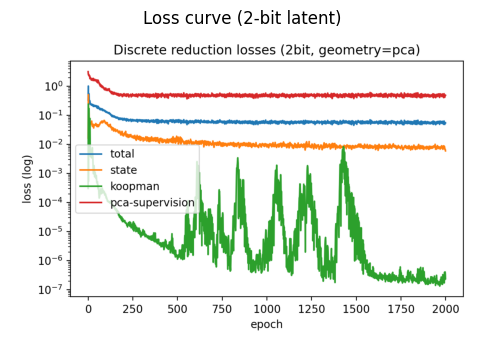

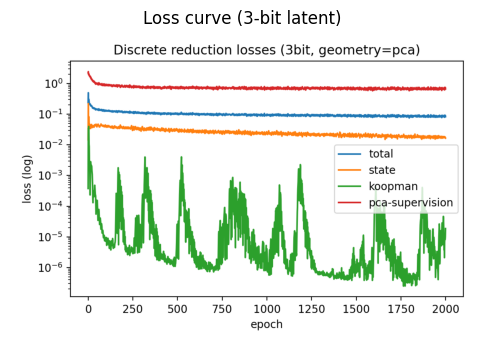

In [22]:
for k in K_LIST:
    d = out_dir_for_k(k)
    loss_path = d / 'reduction_losses.png'
    show_image(loss_path, title=f'Loss curve ({k}-bit latent)')


## Latent dynamics visualization

### k=2
- Loads `latent_dynamics_2d_streamplot.png`

### k=3
- Loads `latent_dynamics_3d_quiver.png`


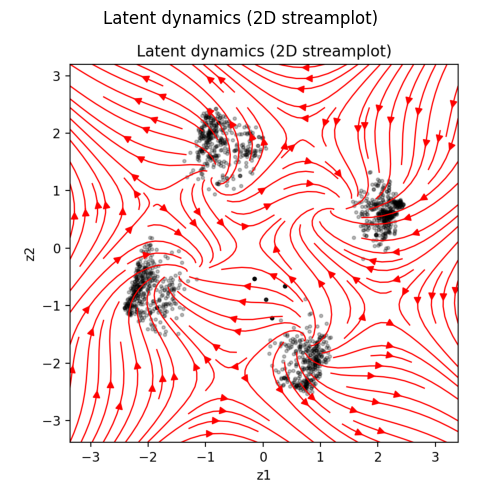

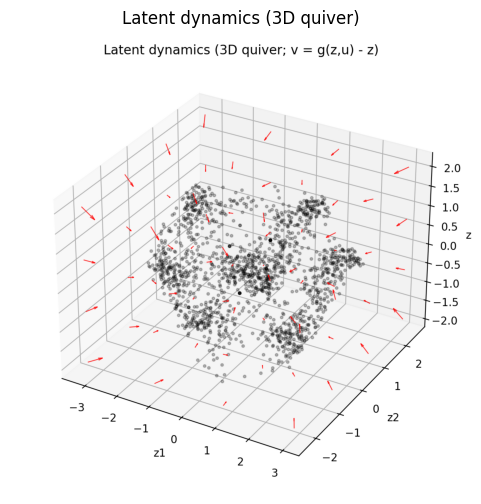

In [23]:
for k in K_LIST:
    d = out_dir_for_k(k)
    if k == 2:
        show_image(d / 'latent_dynamics_2d_streamplot.png', title='Latent dynamics (2D streamplot)')
    elif k == 3:
        show_image(d / 'latent_dynamics_3d_quiver.png', title='Latent dynamics (3D quiver)')
    else:
        print(f'No visualization hard-coded for k={k}')


## PCA on high-D RNN hidden states (k=2) and reduced projections

This cell regenerates a roll-out using the trained `k=2` RNN checkpoint, computes a PCA of the **high-D hidden states** in the original space, and then shows the **reduced latent trajectories** obtained by the trained encoder.


Saved: /home/kabird/separatrix_locator/results/discrete_reduction_flipflop/2bit_latent2_hidden64/pca_hidden_vs_latent.png


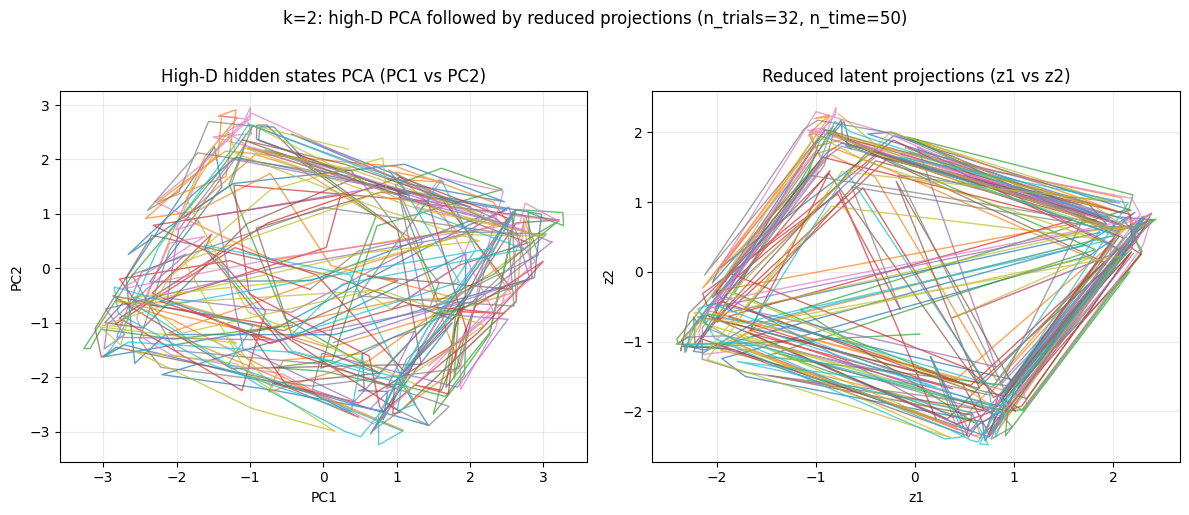

In [24]:
# High-D PCA (hidden) vs reduced latent projection (encoder) for k=2

from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

from separatrix_locator.dynamics.flipflop_task import FlipFlopDataset
from separatrix_locator.dynamics.rnn_training import build_rnn_model
from separatrix_locator.reduction import EncoderNN
from separatrix_locator.reduction.trajectory_utils import rollout_rnn_hidden_states


# Must match the experiment script defaults (unless you changed them there).
seed = 0
rnn_cell_type = "GRU"  # script default
reduction_hidden_dim = 256
reduction_num_layers = 3

k = 2
out_dir = out_dir_for_k(k)

# --- load trained RNN checkpoint ---
rnn_ckpt = out_dir / f"rnn_{k}bit_{rnn_cell_type}_hidden{hidden_size}.pt"
if not rnn_ckpt.exists():
    raise FileNotFoundError(f"Missing RNN checkpoint: {rnn_ckpt}")

rnn_model = build_rnn_model(
    input_size=k,
    output_size=k,
    hidden_size=hidden_size,
    cell_type=rnn_cell_type,
).to("cpu")

state = torch.load(rnn_ckpt, map_location="cpu")
rnn_model.load_state_dict(state)
rnn_model.eval()

# --- load trained encoder ---
reduction_ckpt = out_dir / "reduction_model.pt"
if not reduction_ckpt.exists():
    raise FileNotFoundError(f"Missing reduction checkpoint: {reduction_ckpt}")

bundle = torch.load(reduction_ckpt, map_location="cpu")
encoder_state = bundle["encoder"] if isinstance(bundle, dict) and "encoder" in bundle else bundle

encoder = EncoderNN(
    input_dim=hidden_size,
    latent_dim=k,
    hidden_dim=reduction_hidden_dim,
    num_layers=reduction_num_layers,
)
encoder.load_state_dict(encoder_state)
encoder.eval()

# --- regenerate known input sequences u_seq ---
# Matches the experiment script's rollout dataset construction:
#   FlipFlopDataset(..., random_seed=args.seed + 1)

dataset = FlipFlopDataset(
    n_trials=n_trials,
    repeats=1,
    n_bits=k,
    n_time=n_time,
    p=p,
    random_seed=seed + 1,
)

u_seq_np, target_seq_np = dataset()  # (T, B, k)
u_seq = torch.from_numpy(u_seq_np).to(dtype=torch.float32)

# --- rollout high-D hidden states x_seq (T, B, D_hidden) ---
# Uses no_grad in rollout utility.
outputs_seq,x_seq = rollout_rnn_hidden_states(rnn_model, u_seq, device=torch.device("cpu"), return_outputs=True)

T, B, D = x_seq.shape
assert D == hidden_size

# --- PCA in high-D hidden space ---
x_flat = x_seq.reshape(T * B, D).detach().cpu().numpy()
pca = PCA(n_components=2)
xy = pca.fit_transform(x_flat)  # (T*B, 2)
xy = xy.reshape(T, B, 2)

# --- project to latent space (encoder) ---
with torch.no_grad():
    z_flat = encoder(x_seq.reshape(T * B, D))  # (T*B, 2)

z = z_flat.reshape(T, B, k).detach().cpu().numpy()  # (T, B, 2)

# --- plot: side-by-side trajectories ---
num_traj_to_show = min(10, B)
traj_ids = list(range(num_traj_to_show))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)

for b in traj_ids:
    ax1.plot(xy[:, b, 0], xy[:, b, 1], alpha=0.7, linewidth=1.0)
    ax2.plot(z[:, b, 0], z[:, b, 1], alpha=0.7, linewidth=1.0)

ax1.set_title("High-D hidden states PCA (PC1 vs PC2)")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
ax1.grid(alpha=0.25)

ax2.set_title("Reduced latent projections (z1 vs z2)")
ax2.set_xlabel("z1")
ax2.set_ylabel("z2")
ax2.grid(alpha=0.25)

plt.suptitle(f"k=2: high-D PCA followed by reduced projections (n_trials={n_trials}, n_time={n_time})", y=1.02)
plt.tight_layout()

plot_path = out_dir / "pca_hidden_vs_latent.png"
fig.savefig(plot_path, dpi=200, bbox_inches="tight")
print("Saved:", plot_path)
plt.show()


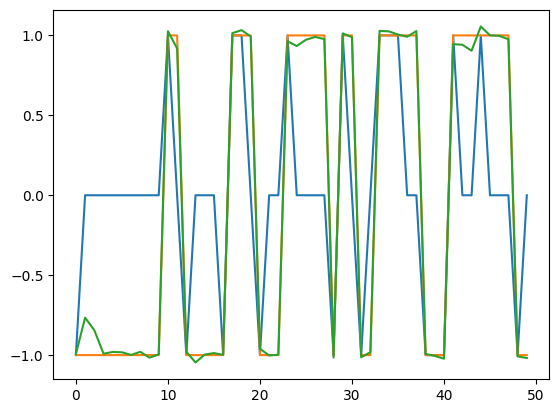

In [25]:
# l=plt.plot(xy[:,:,0].T,xy[:,:,1].T)
plt.plot(u_seq[:,0,0])
plt.plot(target_seq_np[:,0,0])
plt.plot(outputs_seq[:,0,0])

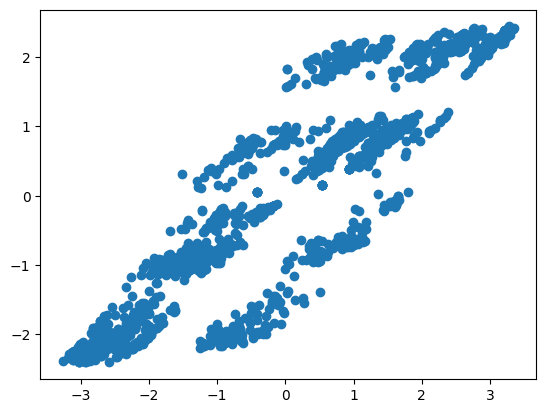

In [27]:
plt.scatter(xy[:,:,0],z[:,:,0])

## Notes

- If images are missing, double-check you used matching settings (at least `hidden_size`).
- The script saves `reduction_model.pt` in each output folder, so you can also write extra cells to reload and inspect the networks.
